# Importing Libraries and Data

In [20]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input
import matplotlib.pyplot as plt
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV
print("Libraries sucessfully imported")

Libraries sucessfully imported


In [2]:
#loading Minset dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Exploring and Visualizing Dataset

In [3]:
x_train = x_train / 255.0
x_test = x_test / 255.0

## Reshape for CNN

In [18]:
x_train_cnn = x_train.reshape(-1, 28, 28, 1)
x_test_cnn = x_test.reshape(-1, 28, 28, 1)

## Build CNN Model

In [21]:
def create_cnn_model(filters_1=32, kernel_size=(3, 3), dense_units=64, optimizer='adam'):
    model = Sequential([
        Input(shape=(28, 28, 1)),
        keras.layers.Conv2D(filters_1, kernel_size, activation='relu'),
        keras.layers.MaxPooling2D((2, 2)),
        
        keras.layers.Conv2D(filters_1 * 2, kernel_size, activation='relu'),
        keras.layers.MaxPooling2D((2, 2)),
        
        keras.layers.Flatten(),
        keras.layers.Dense(dense_units, activation='relu'),
        keras.layers.Dense(10, activation='softmax')
    ])
    
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [22]:
# 1. Wrap the model
model_wrapper = KerasClassifier(model=create_cnn_model, verbose=0)

# 2. Define the grid of hyperparameters to test
param_grid = {
    'model__filters_1': [16, 32],
    'model__dense_units': [32, 64],
    'optimizer': ['adam', 'rmsprop'],
    'batch_size': [32, 64],
    'epochs': [5]
}

# 3. Setup Grid Search with 3-fold cross-validation
grid = GridSearchCV(estimator=model_wrapper, param_grid=param_grid, cv=3, n_jobs=-1)

# 4. Run the search on a subset
print("Starting CNN Grid Search...")
grid_result = grid.fit(x_train_cnn[:5000], y_train[:5000])

print(f"Best CNN Parameters: {grid_result.best_params_}")

Starting CNN Grid Search...
Best CNN Parameters: {'batch_size': 32, 'epochs': 5, 'model__dense_units': 64, 'model__filters_1': 32, 'optimizer': 'rmsprop'}


In [23]:

best_params = grid_result.best_params_

cnn_model = create_cnn_model(
    filters_1=best_params['model__filters_1'],
    dense_units=best_params['model__dense_units'],
    optimizer=best_params['optimizer']
)


print("Starting Final CNN Training with Optimized Parameters...")
history_cnn = cnn_model.fit(
    x_train_cnn, 
    y_train,
    epochs=10, # Increasing epochs to 10 for final convergence
    batch_size=best_params['batch_size'],
    validation_split=0.1
)

Starting Final CNN Training with Optimized Parameters...
Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9531 - loss: 0.1481 - val_accuracy: 0.9817 - val_loss: 0.0626
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9849 - loss: 0.0485 - val_accuracy: 0.9870 - val_loss: 0.0464
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9900 - loss: 0.0340 - val_accuracy: 0.9885 - val_loss: 0.0437
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9920 - loss: 0.0263 - val_accuracy: 0.9898 - val_loss: 0.0410
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9939 - loss: 0.0201 - val_accuracy: 0.9908 - val_loss: 0.0362
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9952 - loss: 0.0168 - val_accuracy: 0.9925 - val_loss: 0.0332
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9959 - loss: 0.0133 - val_accuracy: 0.9912 - val_loss: 0.0371
Epoch 8/10
1688/1688 ━━━━━

## Evaluate on Clean Data

In [24]:
# Testing how well the CNN performs on the original, unmodified test dataset
test_loss_cnn, test_acc_cnn = cnn_model.evaluate(x_test_cnn, y_test)
print("CNN Test Accuracy:", test_acc_cnn)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9921 - loss: 0.0452
CNN Test Accuracy: 0.9921000003814697


## Add Same Noise as FNN

In [25]:
def add_impulsive_noise(image, noise_factor=0.1):
    """
    Add impulsive noise to an image.
    Parameters:
        - image: The image (2D or 3D array) to add noise to.
        - noise_factor: Proportion of image pixels to modify.
    """
    np.random.seed(42)

    noisy_image = image.copy()

    #set some pixels to 1
    white_pixels = np.random.rand(*image.shape) < (noise_factor / 2)
    noisy_image[white_pixels] = 1

    # set some pixels to 0
    black_pixels = np.random.rand(*image.shape) < (noise_factor / 2)

    noisy_image[black_pixels] = 0

    return noisy_image


In [26]:
clean_images_subset_cnn = x_test_cnn[:2000]
subset_labels = y_test[:2000]

x_test_noisy_raw = add_impulsive_noise(x_test, noise_factor=0.1)
noisy_images_subset_cnn = x_test_noisy_raw[:2000].reshape(-1, 28, 28, 1)

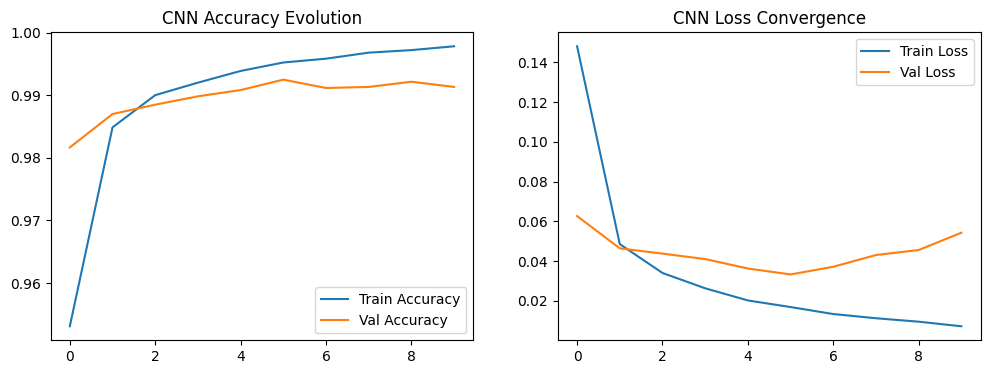

In [27]:
plt.figure(figsize=(12, 4)) 

plt.subplot(1, 2, 1) 
plt.plot(history_cnn.history['accuracy'], label='Train Accuracy') 
plt.plot(history_cnn.history['val_accuracy'], label='Val Accuracy')
plt.title('CNN Accuracy Evolution') 
plt.legend() 

plt.subplot(1, 2, 2) 
plt.plot(history_cnn.history['loss'], label='Train Loss') 
plt.plot(history_cnn.history['val_loss'], label='Val Loss') 
plt.title('CNN Loss Convergence') 
plt.legend() 

plt.show() 

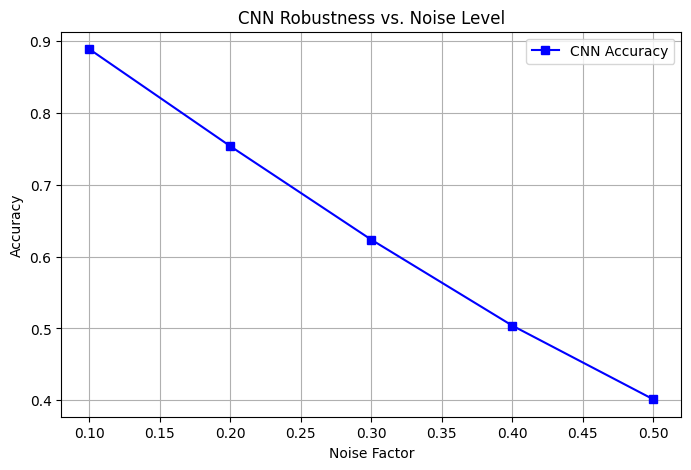

In [28]:
noise_levels = [ 0.1, 0.2, 0.3, 0.4, 0.5]
cnn_accuracies = []

for level in noise_levels:
    x_noisy_temp = add_impulsive_noise(x_test, noise_factor=level)
    x_noisy_subset = x_noisy_temp[:2000].reshape(-1, 28, 28, 1)
    _, acc = cnn_model.evaluate(x_noisy_subset, subset_labels, verbose=0)
    cnn_accuracies.append(acc)

plt.figure(figsize=(8, 5))
plt.plot(noise_levels, cnn_accuracies, marker='s', color='blue', label='CNN Accuracy')
plt.title('CNN Robustness vs. Noise Level')
plt.xlabel('Noise Factor')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.show()

In [29]:
clean_loss_cnn, clean_acc_cnn = cnn_model.evaluate(clean_images_subset_cnn, subset_labels, verbose=0)
print(f"CNN Clean Accuracy (Subset): {clean_acc_cnn:.4f}") 

noisy_loss_cnn, noisy_acc_cnn = cnn_model.evaluate(noisy_images_subset_cnn, subset_labels, verbose=0)
print(f"CNN Noisy Accuracy (Subset): {noisy_acc_cnn:.4f}") 

print(f"CNN Accuracy Drop: {clean_acc_cnn - noisy_acc_cnn:.4f}") 

CNN Clean Accuracy (Subset): 0.9890
CNN Noisy Accuracy (Subset): 0.8885
CNN Accuracy Drop: 0.1005


## Model Comparison & Final Conclusion

**Results:**
* FNN (Optimized via Grid Search): 95.15% (Clean Subset) | 90.30% (Noisy Subset)
* CNN (Optimized via Grid Search): 98.90% (Clean Subset) | 88.85% (Noisy Subset)

**Conclusion:**
The CNN outperformed the FNN on the original, clean dataset, achieving a superior subset accuracy of 98.90% compared to 95.15% for the FNN. This is because the FNN flattens 2D images into 1D vectors, which destroys the spatial relationships between pixels. In contrast, the CNN preserves the 2D structure of the image. Its convolutional and pooling layers act as feature extractors that recognize local spatial patterns, such as edges and curves, making the CNN significantly more accurate on standard data.

While the CNN’s specialized feature extraction leads to higher overall test accuracy (99.21% vs 96.27%), it proved more sensitive to impulsive noise in this experiment, showing a 10.05% drop in accuracy compared to the FNN's 4.85% drop. This suggests that the global connectivity of an optimized FNN can sometimes offer more resilience to pixel-level distortions, even though the CNN remains the superior model for general image recognition.